In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os
print(os.listdir())

import warnings
warnings.filterwarnings('ignore')

['.ipynb_checkpoints', 'heart.csv', 'Heart_Disease.ipynb']


# Data Collection & preprocessing

In [43]:
df = pd.read_csv("heart.csv")

In [44]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [45]:
type(df)

pandas.core.frame.DataFrame

In [46]:
df.shape

(303, 14)

In [47]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [48]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
144,76,0,2,140,197,0,2,116,0,1.1,1,0,2,1
13,64,1,3,110,211,0,0,144,1,1.8,1,0,2,1
199,65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
170,56,1,2,130,256,1,0,142,1,0.6,1,1,1,0


In [49]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [51]:
info = ["age","1: male, 0: female","chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic","resting blood pressure"," serum cholestoral in mg/dl","fasting blood sugar > 120 mg/dl","resting electrocardiographic results (values 0,1,2)"," maximum heart rate achieved","exercise induced angina","oldpeak = ST depression induced by exercise relative to rest","the slope of the peak exercise ST segment","number of major vessels (0-3) colored by flourosopy","thal: 3 = normal; 6 = fixed defect; 7 = reversable defect"]

for i in range(len(info)):
    print(df.columns[i]+":\t\t\t"+info[i])

age:			age
sex:			1: male, 0: female
cp:			chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic
trestbps:			resting blood pressure
chol:			 serum cholestoral in mg/dl
fbs:			fasting blood sugar > 120 mg/dl
restecg:			resting electrocardiographic results (values 0,1,2)
thalach:			 maximum heart rate achieved
exang:			exercise induced angina
oldpeak:			oldpeak = ST depression induced by exercise relative to rest
slope:			the slope of the peak exercise ST segment
ca:			number of major vessels (0-3) colored by flourosopy
thal:			thal: 3 = normal; 6 = fixed defect; 7 = reversable defect


In [52]:
df["target"].describe()

count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

In [53]:
df["target"].unique()

array([1, 0])

In [54]:
print(df.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


target
1    165
0    138
Name: count, dtype: int64


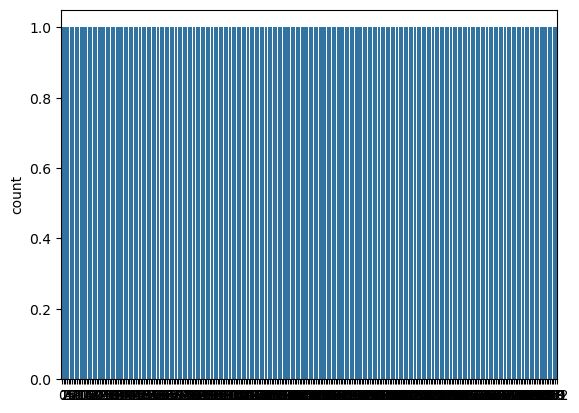

In [55]:
y = df["target"]

sns.countplot(y)


target_temp = df.target.value_counts()

print(target_temp)

In [56]:
countNoDisease = len(df[df.target == 0])
countHaveDisease = len(df[df.target == 1])

In [57]:
countNoDisease

138

In [58]:
countHaveDisease

165

In [59]:
df["sex"].unique()

array([1, 0])

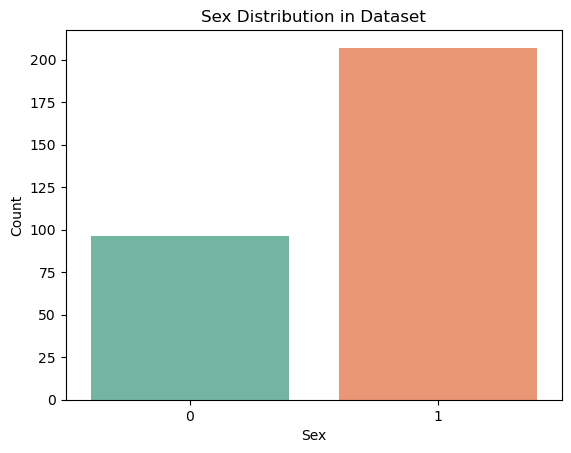

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="sex", data=df, palette="Set2")
plt.title("Sex Distribution in Dataset")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [61]:
df["cp"].unique()

array([3, 2, 1, 0])

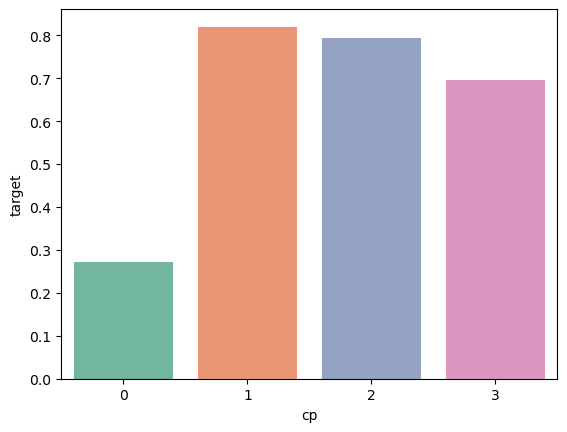

In [62]:
sns.barplot(x=df["cp"],y=y,ci=None,palette="Set2")
plt.show()

In [63]:
df["fbs"].describe()

count    303.000000
mean       0.148515
std        0.356198
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: fbs, dtype: float64

In [64]:
df["fbs"].unique()

array([1, 0])

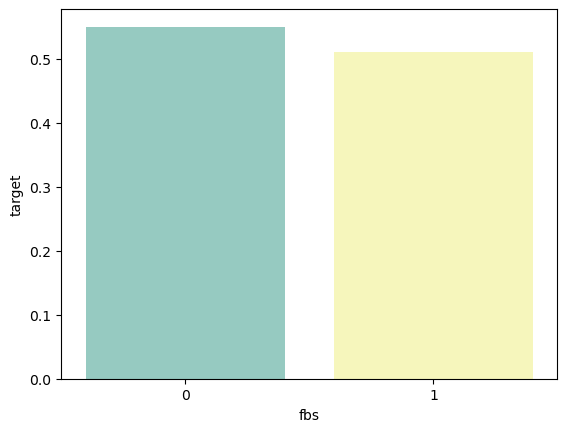

In [65]:
sns.barplot(x=df["fbs"],y=y,ci=None, palette="Set3")
plt.show()

In [66]:
df["restecg"].unique()

array([0, 1, 2])

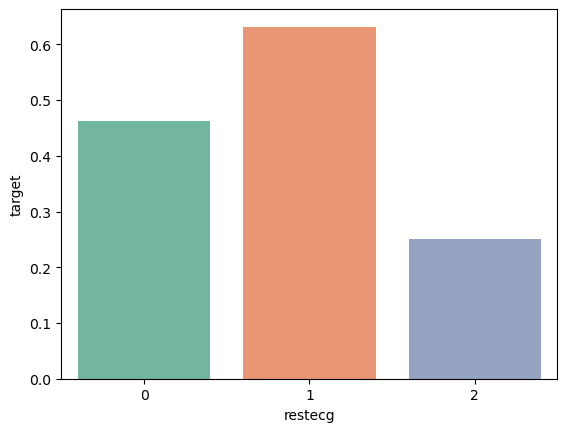

In [67]:
sns.barplot(x=df["restecg"],y=y,ci=None,palette="Set2")
plt.show()

In [68]:
df["exang"].unique()

array([0, 1])

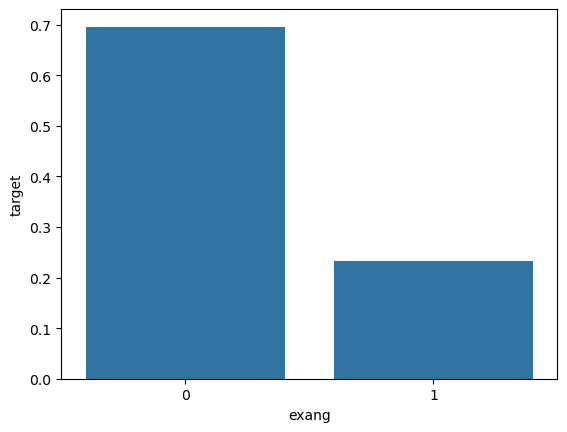

In [69]:
sns.barplot(x=df["exang"],y=y,ci=None)
plt.show()

In [70]:
df["slope"].unique()

array([0, 2, 1])

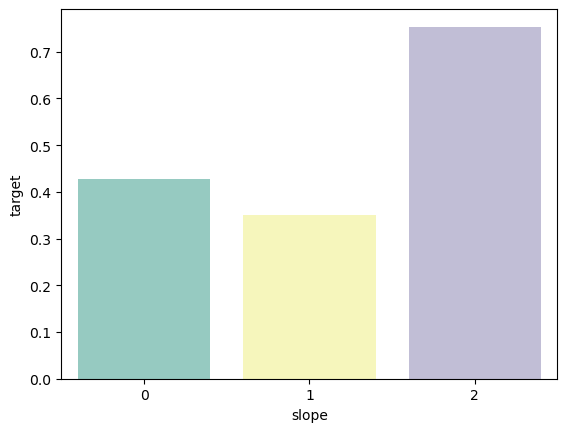

In [71]:
sns.barplot(x=df["slope"],y=y,ci=None,palette="Set3")
plt.show()

In [72]:
df["ca"].unique()

array([0, 2, 1, 3, 4])

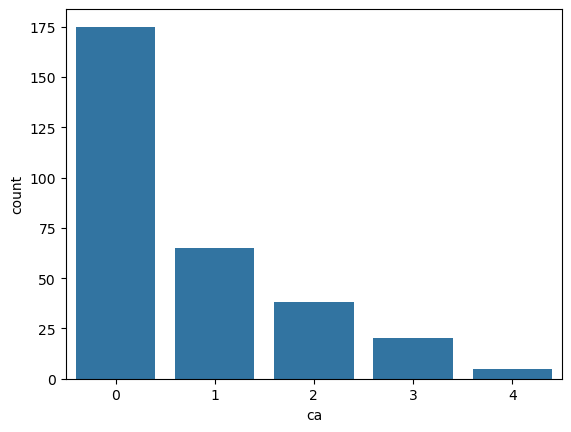

In [73]:
sns.countplot(x=df["ca"])
plt.show()

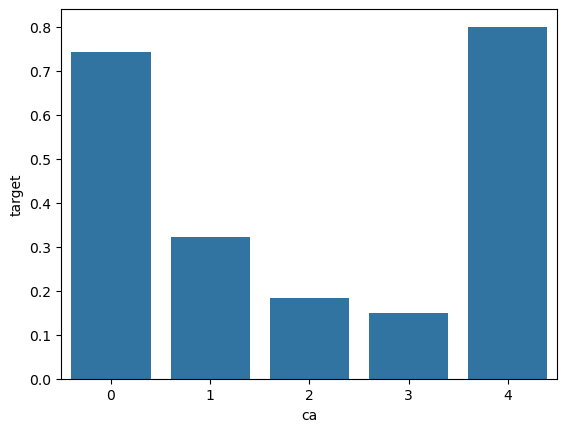

In [74]:
sns.barplot(x=df["ca"],y=y,ci=None)
plt.show()

In [75]:
df["thal"].unique()

array([1, 2, 3, 0])

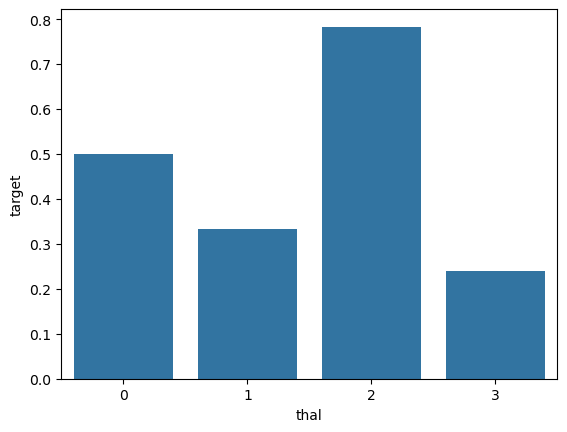

In [76]:
sns.barplot(x=df["thal"],y=y,ci=None)
plt.show()

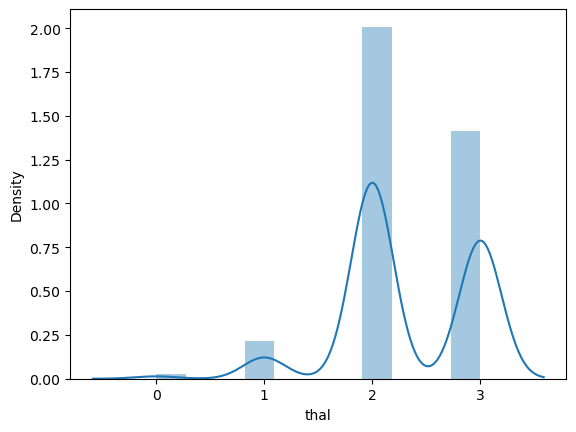

In [77]:
sns.distplot(df["thal"])
plt.show()

In [78]:
from sklearn.model_selection import train_test_split

predictors = df.drop("target",axis=1)
target = df["target"]

X_train,X_test,Y_train,Y_test = train_test_split(predictors,target,test_size=0.20,random_state=0)

In [79]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [81]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, Y_train)

,n_estimators,30
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
from sklearn.metrics import accuracy_score
Y_pred = model.predict(X_test)

score_rf = round(accuracy_score(Y_test, Y_pred) * 100, 2)
print("Accuracy:", score_rf, "%")

Accuracy: 88.52 %


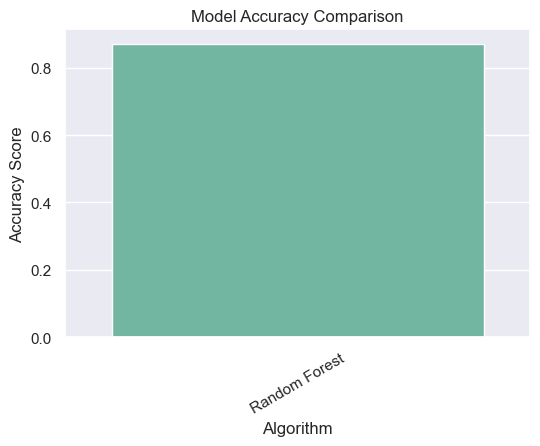

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt


# Example: replace score_rf with your actual accuracy value
score_rf = 0.87  

# Wrap data in a DataFrame (best practice for Seaborn)
results = pd.DataFrame({
    "Algorithm": ["Random Forest"],
    "Accuracy": [score_rf]
})

# Set figure size
sns.set(rc={'figure.figsize':(6,4)})

# Create barplot
sns.barplot(x="Algorithm", y="Accuracy", data=results, palette="Set2")

# Add labels and title
plt.xlabel("Algorithm")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")

# Rotate x-axis labels if needed
plt.xticks(rotation=30)

plt.show()


In [86]:
import numpy as np

print("Enter patient details")

age = float(input("Age: "))
gender = float(input("Gender (0 = Female, 1 = Male): "))
cp = float(input("Chest Pain Type (0-3): "))
trestbps = float(input("Resting Blood Pressure: "))
chol = float(input("Cholesterol: "))
fbs = float(input("Fasting Blood Sugar (0/1): "))
restecg = float(input("Rest ECG (0-2): "))
thalach = float(input("Max Heart Rate: "))
exang = float(input("Exercise Induced Angina (0/1): "))
oldpeak = float(input("ST Depression: "))
slope = float(input("Slope (0-2): "))
ca = float(input("Number of Major Vessels (0-3): "))
thal = float(input("Thal (1-3): "))

input_data = np.array([[age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal]])

prediction =model.predict(input_data)

if prediction[0] == 1:
    print("Result: Person has Heart Disease")
else:
    print("Result: Person does not have Heart Disease")

Enter patient details


Age:  67
Gender (0 = Female, 1 = Male):  1
Chest Pain Type (0-3):  0
Resting Blood Pressure:  160
Cholesterol:  286
Fasting Blood Sugar (0/1):  0
Rest ECG (0-2):  0
Max Heart Rate:  108
Exercise Induced Angina (0/1):  1
ST Depression:  1.5
Slope (0-2):  1
Number of Major Vessels (0-3):  3
Thal (1-3):  2


Result: Person does not have Heart Disease


In [87]:
!pip install joblib

In [88]:
import joblib

In [92]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [90]:
pip install flask

Note: you may need to restart the kernel to use updated packages.
